# NYC Taxi Trip Duration


## Description:
The competition dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform. The data was originally published by the NYC Taxi and Limousine Commission (TLC). The data was sampled and cleaned for the purposes of this playground competition. Based on individual trip attributes, participants should predict the duration of each trip in the test set.

The dataset contains the following fields: 
- **id** - a unique identifier for each trip 
- **vendor_id** - a code indicating the provider associated with the trip
- **pickup_datetime** - date and time when the meter was engaged  
- **passenger_count** - the number of passengers in the vehicle
- **pickup_longitude** - the longitude where the meter was engaged 
- **pickup_latitude** - the latitude where the meter was engaged
- **dropoff_longitude** - the longitude where the meter was disengaged 
- **dropoff_latitude** - the latitude where the meter was disengaged 
- **store_and_fwd_flag** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward 
- **trip trip_duration** - duration of the trip in seconds
---------------------------------------------------------------------------
Acknowledgement:
 [dataset](https://www.kaggle.com/c/nyc-taxi-trip-duration/data?select=sample_submission.zip)


Objective:
Understand the Dataset & cleanup (if required).
Build Regression models to predict the duration of taxi trip.
Also evaluate the models & compare their respective scores like R2, RMSE,etc!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

df=pd.read_csv('D:/Python/ML/projects/1 project-nyc-taxi-trip-duration/data/raw/train.csv')
df.shape


(1000000, 10)

In [3]:
pd.options.display.max_columns=None
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  str    
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  str    
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  str    
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 76.3 MB


In [5]:
df.drop(columns=['id'],inplace=True)
df["pickup_datetime"]=pd.to_datetime(df['pickup_datetime'])


In [6]:
df.isnull().any()

vendor_id             False
pickup_datetime       False
passenger_count       False
pickup_longitude      False
pickup_latitude       False
dropoff_longitude     False
dropoff_latitude      False
store_and_fwd_flag    False
trip_duration         False
dtype: bool

In [7]:
df.columns=(
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ",'_')
    .str.replace('-','_')
    .str.replace('[^a-z0-9_]',"",regex=True)

)
df.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration'],
      dtype='str')

In [8]:
df[['passenger_count', 'pickup_longitude',
    'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag', 'trip_duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_count,1000000.0,1.665353,1.315723,0.000000,1.000000,1.000000,2.000000,7.000000e+00
pickup_longitude,1000000.0,-73.973475,0.065404,-121.933342,-73.991852,-73.981728,-73.967346,-6.133553e+01
pickup_latitude,1000000.0,40.750947,0.033745,34.359695,40.737372,40.754131,40.768379,5.188108e+01
dropoff_longitude,1000000.0,-73.973421,0.065432,-121.933304,-73.991341,-73.979767,-73.963036,-6.133553e+01
dropoff_latitude,1000000.0,40.751829,0.035782,34.359695,40.735928,40.754551,40.769833,4.392103e+01
trip_duration,1000000.0,954.884971,3882.070116,1.000000,397.000000,662.000000,1074.000000,2.227612e+06


### Key Observations : 
- There is No Null Values 
- There minimum value in *Trip_Duration* is **1 sec** and maximum value is approximately **26 Days** these aren't possible
- The Minimum number Of *passenger_count* is 0 which isn't possible 

- The minimum and maximum values of the *pickup_latitude* and *dropoff_latitude*  indicates that might be  impossible values as the NYC latitude ranges from 40.5° N to 45.0° N (positive values),The same goes for *pickup_longitude* and *dropoff_longitude* as the NYC longitude ranges from  71.85° W to 79.76° W ( negative values).



#### Data Cleaning

**changing the unrealistic** *trip_duration*:
- we will cap it between 1min and 4h 

**changing the unrealistic** *passenger_count*:

- according to [NYC Taxi & Limousine Commission](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page) the the passenger count ranges from 1-5 

**changing the unrealistic** *longitudes and latitudes*:
- NYC *latitude* ranges from 40.4°N to 41.0°N (positive values).
- NYC *longitude* ranges from  74.3°W, 73.6°W ( negative values).

In [9]:

#trip duration cleaning 
df = df[df['trip_duration'].between(60, 10800)]
df.shape


(992734, 9)

In [10]:
df=df[df['passenger_count'].between(1,5)]
df.shape

(959639, 9)

In [11]:
df = df[
(df['pickup_latitude'].between(40.4, 41.0))&
(df['pickup_longitude'].between(-74.3, -73.6))&
(df['dropoff_latitude'].between(40.4, 41.0))&
(df['dropoff_longitude'].between(-74.3, -73.6))
]
df.shape

(959289, 9)

In [12]:
df[['passenger_count', 'pickup_longitude',
    'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag', 'trip_duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
passenger_count,959289.0,1.516729,1.059315,1.000000,1.000000,1.000000,2.000000,5.000000
pickup_longitude,959289.0,-73.973611,0.037763,-74.289017,-73.991867,-73.981758,-73.967484,-73.605400
pickup_latitude,959289.0,40.751000,0.027881,40.413231,40.737408,40.754143,40.768364,40.991917
dropoff_longitude,959289.0,-73.973563,0.035034,-74.292992,-73.991341,-73.979797,-73.963150,-73.602089
dropoff_latitude,959289.0,40.751854,0.031995,40.416168,40.735958,40.754559,40.769814,40.996639
trip_duration,959289.0,840.024117,654.426015,60.000000,400.000000,664.000000,1075.000000,10704.000000


#### Univariate analysis


##### Trip Duration

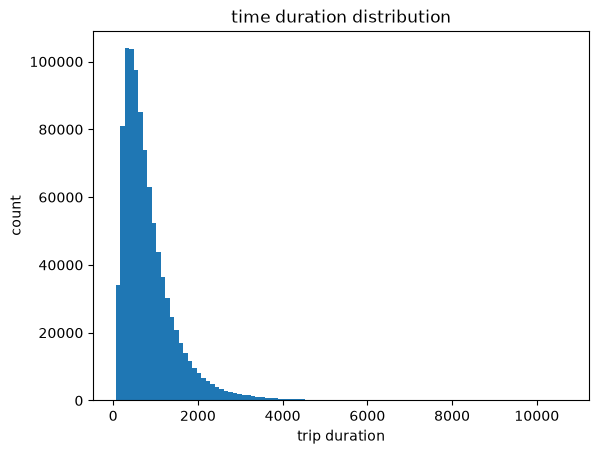

In [13]:
plt.Figure(figsize=(10,10))
plt.hist(df.trip_duration,bins=100)
plt.xlabel("trip duration")
plt.ylabel("count")
plt.title("time duration distribution")
plt.show()

### Key Observation : 
- See That The trip_duration distribution is Right Skewed , We Can Try and take  Logarithm(1+trip_duration) to make the distribution more like normal distribution

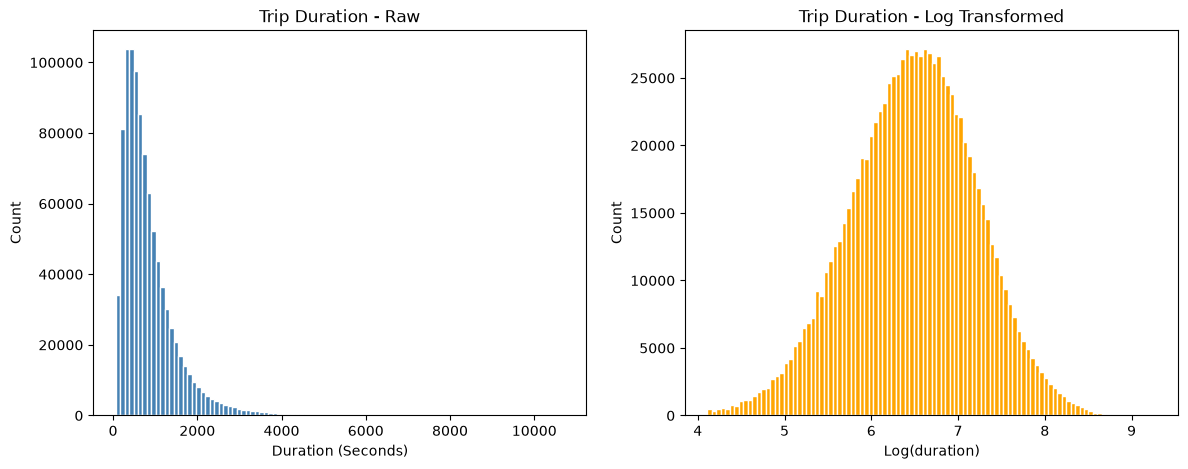

In [14]:

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df.trip_duration,bins=100,color='steelblue',edgecolor='white')
axes[0].set_title('Trip Duration - Raw')
axes[0].set_xlabel('Duration (Seconds)')
axes[0].set_ylabel('Count')



axes[1].hist(np.log1p(df.trip_duration),bins=100,color='orange',edgecolor='white')
axes[1].set_title('Trip Duration - Log Transformed')
axes[1].set_xlabel('Log(duration)')
axes[1].set_ylabel('Count')
plt.show()



### Key Observation: 
- After Applying Log-Transformation We see the Data Is almost perfectly Symmetrical, so We apply use Log-Transformation To *trip_duration* 

#### passenger_count

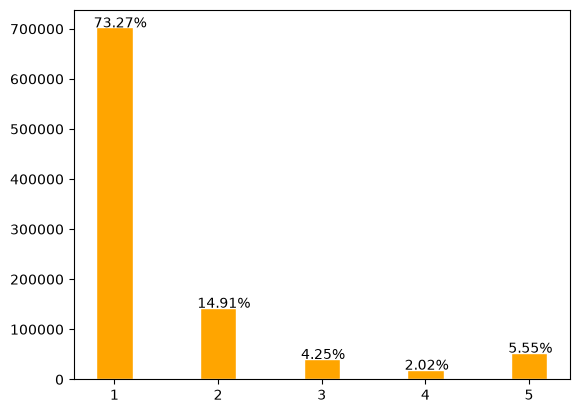

In [15]:
# passenger_count cleaning
passenger=df.passenger_count.value_counts().sort_index()
plt.bar(passenger.index,passenger.values,color='orange',edgecolor='white',width=0.35)

for i in passenger.index:
    plt.text(x=i-0.20,y=passenger[i],s=f"{((passenger[i]/passenger.values.sum())*100):.2f}%")
plt.show()


### Key Observation: 
- you can see that:
   - 73.27% of trips had *1 passenger*, **dominant** than the other
   - 14.91% of trips had **2 passenger**,**second** most frequent
   - 4.25% of trips had **3 passenger**,huge **drop off**
   - 2.02%of trips had **4 passenger**
   - 5.55% of trips had **5 passenger**,**better** than 3 and 4

#### vendor_id


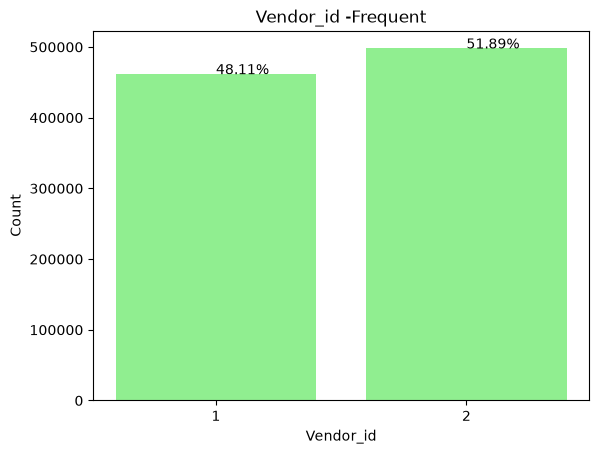

In [16]:
vend_id=df.vendor_id.value_counts().sort_index()
plt.title("Vendor_id -Frequent")
plt.xlabel("Vendor_id")
plt.ylabel("Count")
plt.bar([1,2],vend_id.values,color="lightgreen")
plt.xticks([1,2])
for i in vend_id.index:
    plt.text(x=i,y=vend_id[i],s=f'{(vend_id[i]/vend_id.values.sum())*100 :.2f}%')
plt.show()

##### key observation:
- We can see that the split is roughly 50/50 no vendor dominates the market

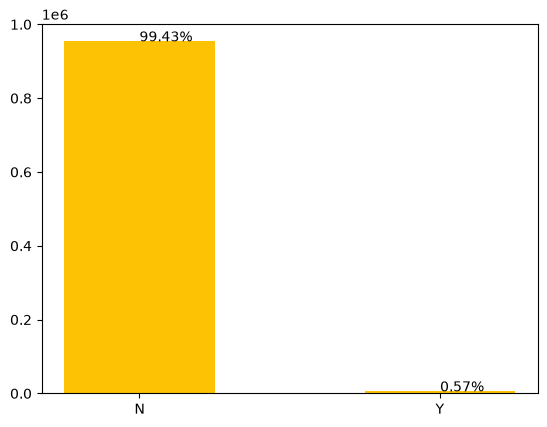

In [17]:
flag=df.store_and_fwd_flag.value_counts()
plt.bar(flag.index,flag.values,color='#fcc203',width=0.5)
for i in flag.index:
    plt.text(x=i,y=flag[i],s=f'{(flag[i]/flag.values.sum())*100 :.2f}%')
plt.show()

### Key Observation:
- 99.5% of trips transmitted data immediately with no connectivity issues. The store_and_fwd_flag is heavily imbalanced and will likely contribute minimal predictive signal to the model.

## Bivariate Analysis

In [18]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration'],
      dtype='str')

##### Vendor_id Vs Passenger_count

Text(0, 0.5, 'Duration')

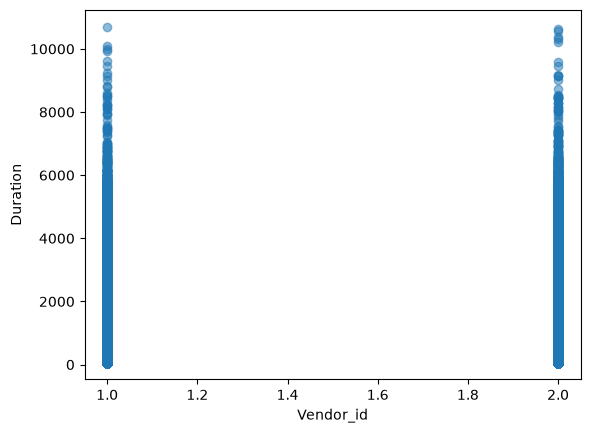

In [19]:
plt.scatter(df.vendor_id,df.trip_duration,alpha=0.5)
plt.xlabel("Vendor_id")
plt.ylabel('Duration')

<Axes: xlabel='vendor_id', ylabel='trip_duration'>

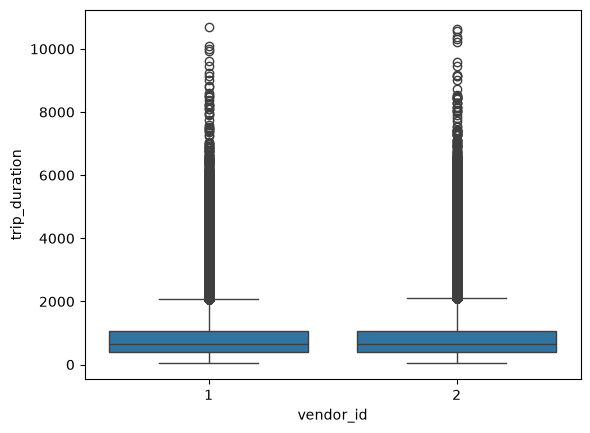

In [20]:
sns.boxplot(x=df.vendor_id,y=df.trip_duration)

### Key observation:
- it seems that there is no clear relation between the vendor-id and the trip_duration

##### passenger_count Vs trip_duration

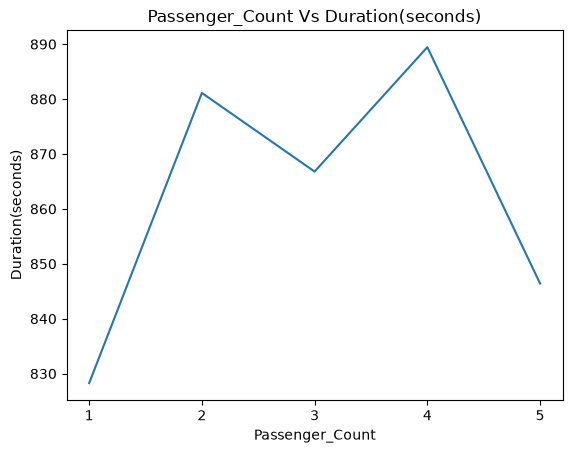

In [21]:
trip_pass=df.groupby('passenger_count',as_index=False)[['trip_duration']].mean()
plt.title("Passenger_Count Vs Duration(seconds)")
plt.xticks(trip_pass['passenger_count'])
plt.xlabel("Passenger_Count")
plt.ylabel('Duration(seconds)')
plt.plot(trip_pass['passenger_count'],trip_pass['trip_duration'])
plt.show()

<Axes: xlabel='passenger_count', ylabel='trip_duration'>

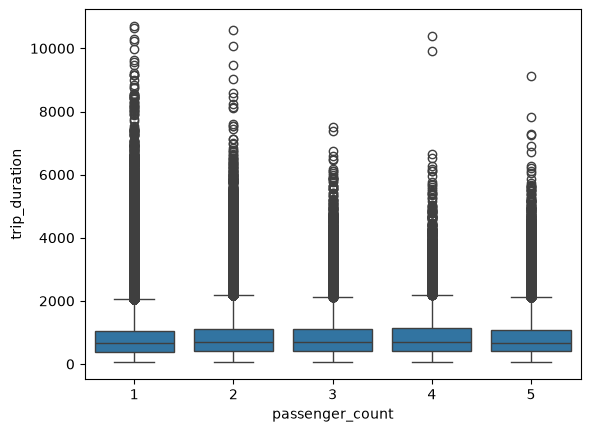

In [22]:
sns.boxplot(x=df.passenger_count,y=df.trip_duration)


<Axes: >

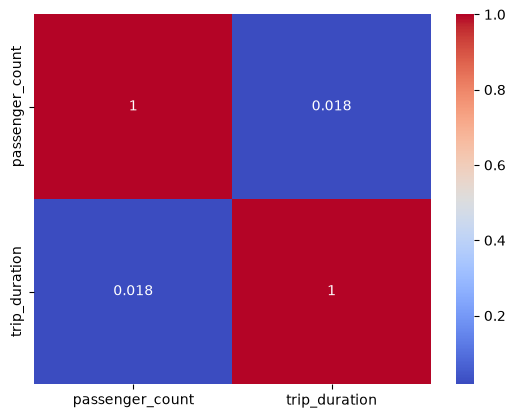

In [23]:
features=['passenger_count', 'trip_duration']
cor=df[features].corr()
sns.heatmap(cor,cmap='coolwarm',annot=True)

#### Key observation : 
- seem like the *passenger_count* doesn't matter as the number of passenger doesn't change the traffic

In [24]:
df.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration'],
      dtype='str')

##### store_and_fwd_flag Vs trip_duration

<Axes: xlabel='store_and_fwd_flag', ylabel='trip_duration'>

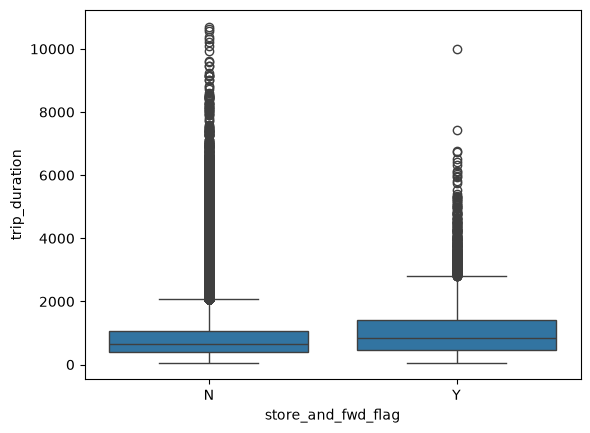

In [25]:
sns.boxplot(x=df.store_and_fwd_flag,y=df.trip_duration)

#### Key Observation: 
- it seems like the Y flag has slightly **lower** trip duration bet this information is an reliable as the Y flag only represents 0.5% of the data

### Speed and Distance


In [26]:
def get_distance(df:pd.DataFrame):
    R=6371.0
    pickup_latitude=np.radians(df['pickup_latitude'])
    dropoff_latitude=np.radians(df['dropoff_latitude'])
    pickup_longitude=np.radians(df['pickup_longitude'])
    dropoff_longitude=np.radians(df['dropoff_longitude'])

    alpha_latitude=df['dropoff_latitude']-df['pickup_latitude']
    alpha_longitude=df['dropoff_longitude']-df['pickup_longitude']

    a=(np.sin(alpha_latitude/2.0))**2+np.cos(pickup_latitude)*np.cos(dropoff_latitude) + \
       np.sin(alpha_longitude/2.0)**2

    c=2*np.atan(np.sqrt(a),np.sqrt(1-a))
    return R*c,(R*c)/df['trip_duration']

In [27]:
df['distance'],df['speed']=get_distance(df)

#### Distance Vs trip_duration


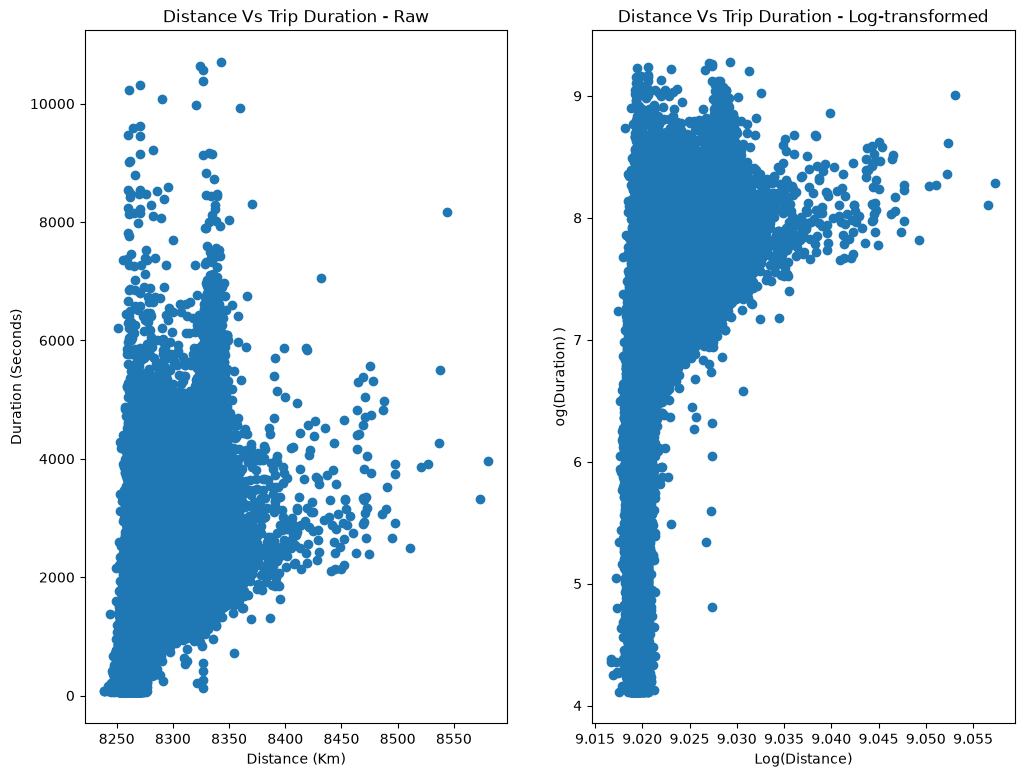

In [ ]:
f,axes=plt.subplots(1,2,figsize=(12,9))

axes[0].scatter(df.distance,df.trip_duration)
axes[0].set_title('Distance Vs Trip Duration - Raw')
axes[0].set_xlabel("Distance (Km)")
axes[0].set_ylabel("Duration (Seconds)")

axes[1].set_title('Distance Vs Trip Duration - Log-transformed')
axes[1].set_xlabel("Log(Distance)")
axes[1].set_ylabel("Log(Duration) )")
axes[1].scatter(np.log1p(df.distance),np.log1p(df.trip_duration))


<Axes: >

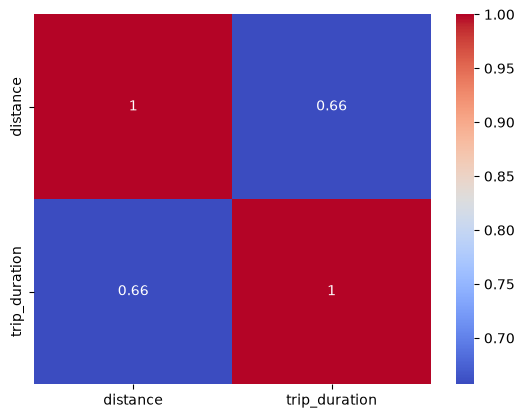

In [29]:
cor=df[['distance','trip_duration']].corr()
sns.heatmap(cor,annot=True,cmap="coolwarm")

### Key observation: 
- We can see that the relation between the distance and trip duration is directly proportional which make sense , how if we take the log of both duration and distance we that we get a nice and linear relation which will be easier to predict 

#### Speed Vs Duration

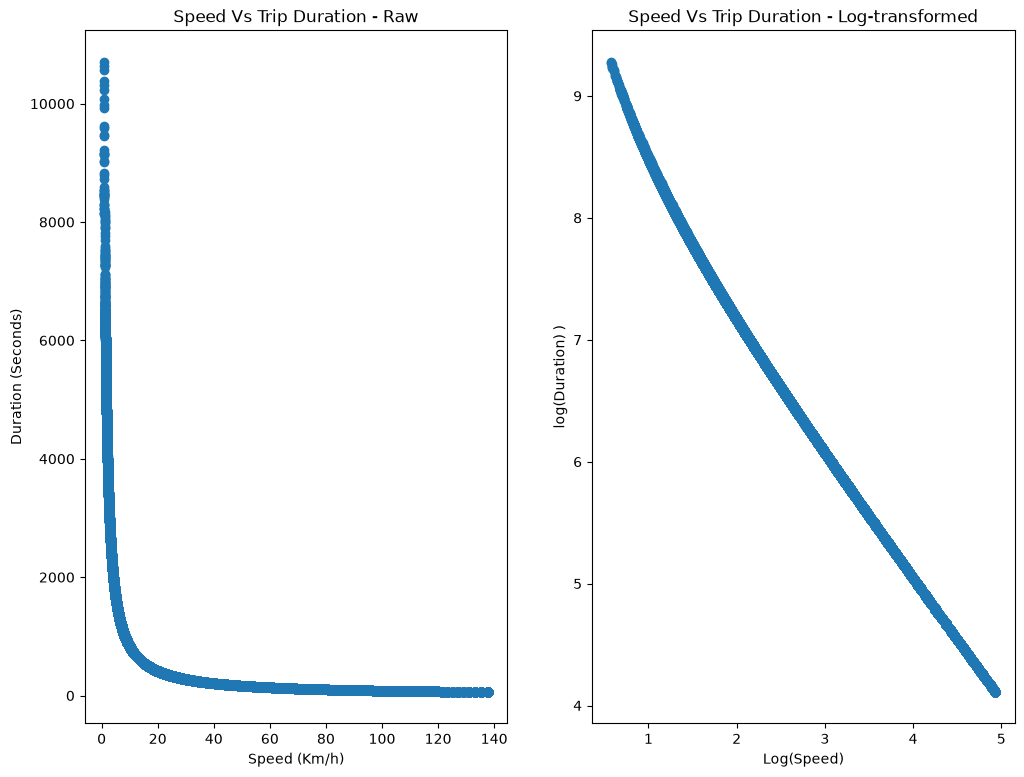

In [30]:
f,axes=plt.subplots(1,2,figsize=(12,9))

axes[0].scatter(df.speed,df.trip_duration)
axes[0].set_title('Speed Vs Trip Duration - Raw')
axes[0].set_xlabel("Speed (Km/h)")
axes[0].set_ylabel("Duration (Seconds)")

axes[1].set_title('Speed Vs Trip Duration - Log-transformed')
axes[1].set_xlabel("Log(Speed)")
axes[1].set_ylabel("log(Duration) )")
axes[1].scatter(np.log1p(df.speed),np.log1p(df.trip_duration))


<Axes: >

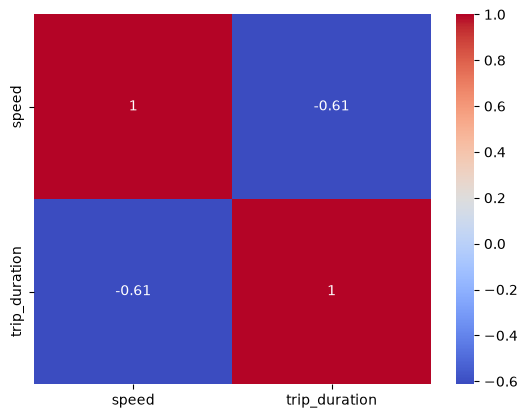

In [31]:
cor=df[['speed','trip_duration']].corr()
sns.heatmap(cor,annot=True,cmap="coolwarm")

#### Key Observation: 
- when the speed increases the trip_duration decrease (inverse relation) which is obvious 
- the log-transformed speed and duration make the data a straight line which is perfect for predictions

#### Temporal Features Vs duration

##### hour Vs duration

In [32]:
df['hour']=df.pickup_datetime.dt.hour

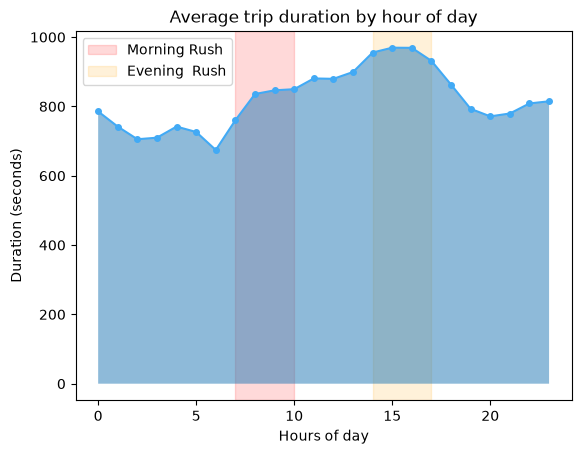

In [33]:
h_trip=df.groupby('hour',as_index=False)[['trip_duration']].mean() 


plt.plot(h_trip['hour'],h_trip['trip_duration'],color='#42aaf5',marker='o',markersize='4')
ticks=[0,200,400,600,800,1000]
plt.yticks(ticks)
plt.title('Average trip duration by hour of day')
plt.xlabel('Hours of day')
plt.axvspan(7,10, alpha = 0.15, color = 'RED', label = 'Morning Rush')
plt.axvspan(14,17,alpha = 0.15, color = 'orange', label = 'Evening  Rush')
plt.fill_between(h_trip['hour'],h_trip['trip_duration'],alpha=0.5)
plt.ylabel('Duration (seconds)')
plt.legend()
plt.show()



### key observation: 
- We can see that the trip_duration during the rush hours are **more** than the other time of the day , his will be a good feature to use in our prediction model !!

In [34]:
df['dayofweek']=df.pickup_datetime.dt.day_of_week
df['dayname']=df.pickup_datetime.dt.day_name()


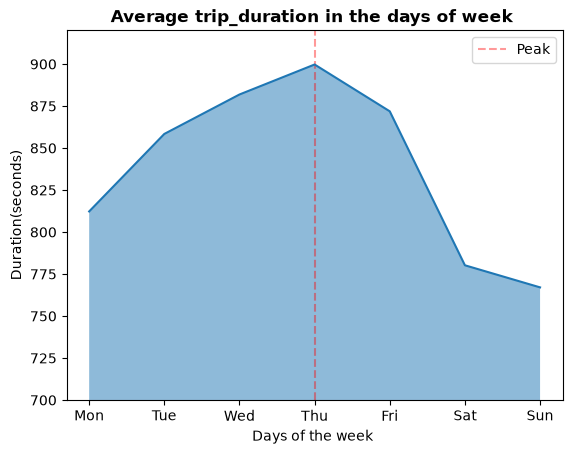

In [35]:

day_trip=df.groupby('dayofweek',as_index=False)[['trip_duration']].mean().sort_index()
plt.ylim(700,920)
plt.xticks(range(7),labels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Average trip_duration in the days of week ",fontweight='bold')
plt.xlabel("Days of the week ")
plt.ylabel('Duration(seconds)')
plt.axvline(3,alpha=0.4, color='red', linestyle='--', label='Peak')
plt.plot(day_trip['dayofweek'],day_trip['trip_duration'])
plt.fill_between(day_trip['dayofweek'],day_trip['trip_duration'],alpha=0.5)
plt.legend()
plt.show()

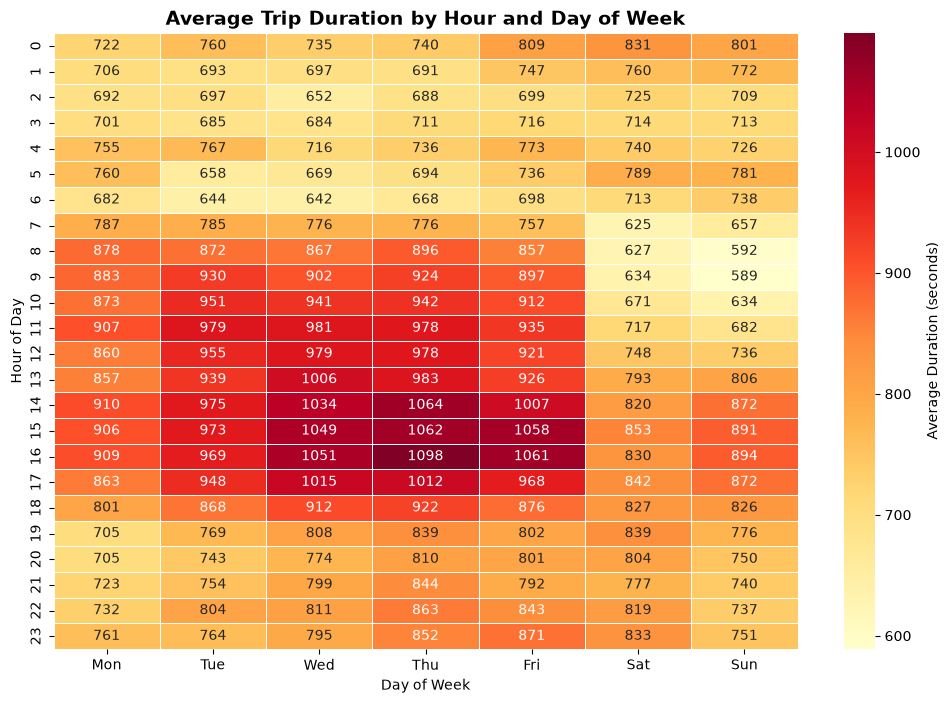

In [36]:
Pivot = df.pivot_table(
    values = 'trip_duration',
    index = 'hour',
    columns = 'dayofweek',
    aggfunc = 'mean'
)
Pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize = (12, 8))
sns.heatmap(
    Pivot,
    cmap = 'YlOrRd',
    annot = True,
    fmt = '.0f',
    ax = ax,
    linewidth = 0.5,
    cbar_kws = {'label': 'Average Duration (seconds)'}
)
ax.set_title('Average Trip Duration by Hour and Day of Week', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.show()

#### Key observation: 
- We see that the trips in Thu at rush hours are the slowest ,which indicates that the traffic is the heaviest on Thu , and that is due to :
    - Midweek Office Peak: Tuesday to Thursday are the main mandatory office days, putting the highest number of commuters on the road.
    - Early Weekend Travel: Drivers start leaving the city on Thursday afternoon to head out of town early, clogging bridges and tunnels.
    - More Rideshares & Deliveries: Business dinners, nightlife, and store restocks bring a rush of Ubers, Lyfts, and delivery trucks onto the streets.
    - Limited Road Space: Narrow streets, construction, and dedicated bus or bike lanes make it hard for heavy traffic to clear out

##### month vs Duration

In [37]:
df['month']=df.pickup_datetime.dt.month
df.month.value_counts()

month
3    168666
4    164896
5    163735
2    157049
6    153871
1    151072
Name: count, dtype: int64

(760.0, 920.0)

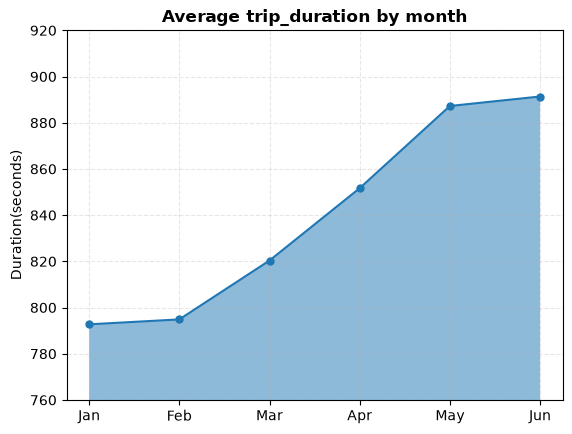

In [38]:
mont_trip=df.groupby('month',as_index=False)[['trip_duration']].mean()
plt.title("Average trip_duration by month",fontweight='bold')
plt.Figure(figsize=(12,10))
plt.plot(mont_trip['month'],mont_trip['trip_duration'],marker='o',markersize='5')
plt.fill_between(mont_trip['month'],mont_trip['trip_duration'],alpha=0.5)
plt.ylabel("Duration(seconds)")
plt.xticks(range(1,7),labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
plt.grid(linestyle='--',alpha=0.3)
plt.ylim(760,920)

#### Key observation : 
- in May and Jun the traffic in heavier than the other months if the year and this is due to : 



    - Roadwork and Repairs: Winter damages roads, so major street paving and construction peak in May and June, causing lane closures.

    - Summer Getaways: Memorial Day kicks off peak weekend travel to places like the Hamptons and Jersey Shore, clogging highways.

    - Graduation Ceremonies: Major colleges and high schools hold graduations, bringing thousands of driving visitors to city venues.

    - Tourism and Events: Great weather brings heavy tourism and major outdoor events (like Fleet Week and the Pride March) that close key      streets.

    - More Deliveries and Taxis: Warmer weather increases outdoor dining, leading to more commercial deliveries and higher ride-share traffic.

### Geographical  Analysis 

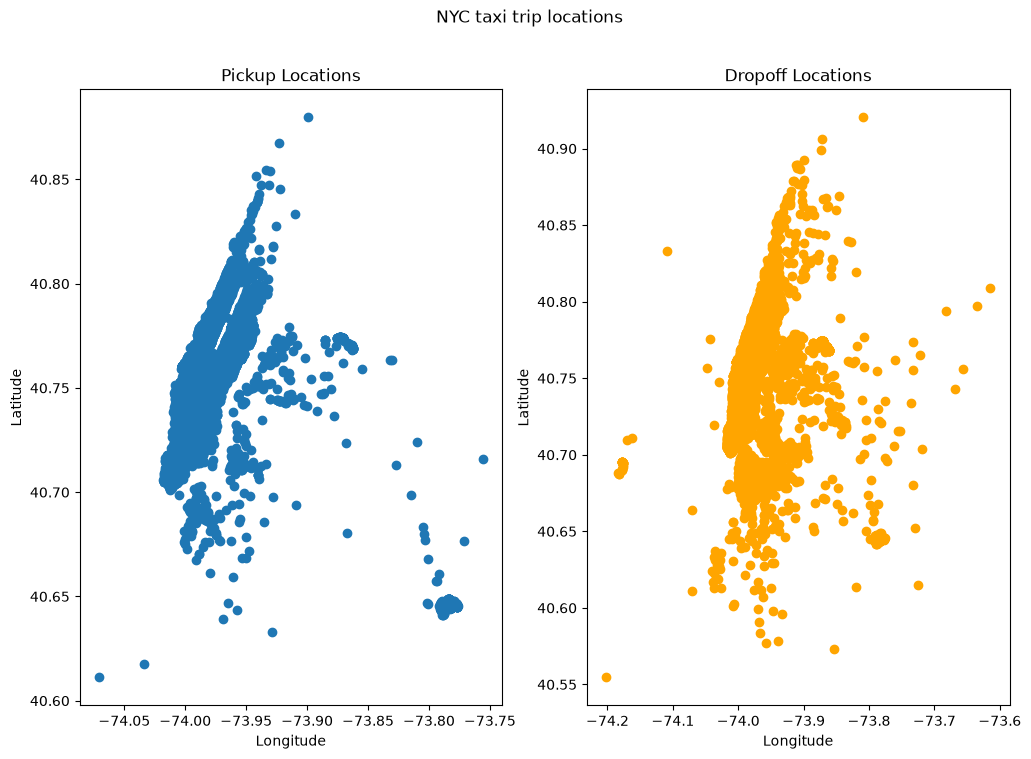

In [39]:
sample=df.sample(10000,random_state=43)
f,ax=plt.subplots(1,2,figsize=(12,8))
plt.suptitle("NYC taxi trip locations")
ax[0].scatter(sample['pickup_longitude'],sample['pickup_latitude'])
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_title("Pickup Locations")

ax[1].scatter(sample['dropoff_longitude'],sample['dropoff_latitude'],color='orange')
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].set_title("Dropoff Locations")

plt.show()

### Key observation:
- As we can see that most of the trips are in manhattan which is due to : 
    - Global Financial Center: Home to Wall Street, the New York Stock Exchange (NYSE), and NASDAQ.


    - Famous Landmarks & Skyscrapers: Features iconic sights like the Empire State Building, Central Park, Times Square, and the Statue of Liberty.


    - Entertainment & Culture: Home to world-renowned Broadway theaters and top-tier museums like The Met and MoMA.


    - Distinct Neighborhoods: Known for vibrant areas like SoHo, Greenwich Village, Chinatown, and Harlem.


    - The NYC Grid System: Famous for its easy-to-navigate layout of numbered avenues and streets.

### Summary : 
- The trip duration is **affected** by :
    - distance
    - speed
    - time of the day
    - day of the week
    - the month

### Columns that will be **dropped**  :

1. id
2. vendor_id 
3. passenger_count
4. store_and_fwd_flag
- as there is no clear relation between these columns  and the Duration of the trip

### Feature Engineering: 
1. pickup_datetime will be turn into:pickup hour ,day of the week ,month
2. longitude and latitude will be turned into  distance



### Finally our selected features will be:
- pickup hour ,day of the week ,month,distance